# Monthly GFS T2M with grib2io + Kerchunk + Icechunk

This notebook builds a **month-long time series of GFS 2-metre temperature (T2M)** from
NOAA's public S3 bucket (`noaa-gfs-bdp-pds`) without downloading the files.

## How it stays fast

Two features combine to make per-file manifest generation near-instant:

1. **`.idx` sidecar** — grib2io automatically fetches the small `url + ".idx"` text file
   that NOAA publishes alongside every GFS file.  This gives message byte offsets
   directly, so grib2io only reads the compact header bytes (Sections 0–5) rather
   than streaming the entire ~500 MB GRIB2 object.

2. **Variable filters** — passing `filters={"shortName": "TMP", ...}` to `open_grib2`
   means only the single T2M message per file is indexed; all other variables are
   skipped.  A full GFS 0.25° file contains ~700 variables; filtering to one reduces
   manifest work by ~700×.

For a full-file example (all variables, VirtualiZarr integration) see
[grib2io_s3_virtualizarr.ipynb](grib2io_s3_virtualizarr.ipynb).

**Dependencies:** `grib2io[icechunk]`, `s3fs`, `matplotlib`


In [1]:
import warnings

import matplotlib.pyplot as plt
import pandas as pd
import xarray as xr

from grib2io.icechunk import open_grib2

warnings.filterwarnings("ignore")

# Optional notebook-only dependency for future VirtualiZarr/object-store workflows.
try:
    from obstore.store import S3Store
    from obspec_utils.registry import ObjectStoreRegistry

    OBSTORE_AVAILABLE = True
except ImportError:
    OBSTORE_AVAILABLE = False

## 1. Configuration

Set the month, grid, and the GRIB2 message filter that selects 2-metre temperature.
`typeOfFirstFixedSurface = 103` is the GRIB2 Table 4.5 code for
*"Specified height level above ground (m)"*, and `level = 2` selects the 2 m level.


In [2]:
BUCKET = "noaa-gfs-bdp-pds"
YEAR = "2025"  # any YYYY present in the bucket
GRID = "0p25"  # 0.25-degree global grid
CYCLE = "00"  # 00Z analysis
FORECAST = "f000"  # analysis hour (zero-lead)

# More tolerant network settings for remote NOAA S3 reads via s3fs/botocore.
storage_options = {
    "anon": True,
    "config_kwargs": {
        "connect_timeout": 30,
        "read_timeout": 120,
        "retries": {"max_attempts": 10, "mode": "adaptive"},
    },
}

# Filter to 2-metre temperature only — skips all other variables during scanning.
# typeOfFirstFixedSurface=103 → "height above ground (m)"; level=2 → 2 m
T2M_FILTERS = {"shortName": "TMP", "typeOfFirstFixedSurface": 103}

# Build URLs for the selected year.
year_start = pd.to_datetime(f"{YEAR}-01-01")
year_end = pd.to_datetime(f"{YEAR}-12-31")
dates = pd.date_range(year_start, year_end, freq="D")
PERIOD_LABEL = YEAR
urls = [f"s3://{BUCKET}/gfs.{d.strftime('%Y%m%d')}/{CYCLE}/atmos/gfs.t{CYCLE}z.pgrb2.{GRID}.{FORECAST}" for d in dates]
urls2 = [f"s3://{BUCKET}/gfs.{d.strftime('%Y%m%d')}/{CYCLE}/atmos/gfs.t{CYCLE}z.pgrb2.{GRID}.f120" for d in dates]
print(f"Period: {PERIOD_LABEL}  ({len(urls)} files)")
print("First:", urls[0])
print("Last: ", urls[-1])

Period: 2025  (365 files)
First: s3://noaa-gfs-bdp-pds/gfs.20250101/00/atmos/gfs.t00z.pgrb2.0p25.f000
Last:  s3://noaa-gfs-bdp-pds/gfs.20251231/00/atmos/gfs.t00z.pgrb2.0p25.f000


## 2. Verify: single file opens quickly

With the `.idx` sidecar + T2M filter, manifest generation should take only a
few seconds even for a 500 MB remote file.


In [3]:
import time

t0 = time.perf_counter()
ds_sample = open_grib2(
    urls[0],
    storage_options=storage_options,
    filters=T2M_FILTERS,
    max_workers=2,
    network_timeout=300,
    max_concurrent_requests=2,
)
print(f"Opened in {time.perf_counter() - t0:.1f}s")
print(ds_sample)

  2026-05-27T14:21:17.425044Z  WARN icechunk_arrow_object_store: The LocalFileSystem storage is not safe for concurrent commits. If more than one thread/process will attempt to commit at the same time, prefer using object stores.
    at icechunk-arrow-object-store/src/lib.rs:196

Opened in 0.5s
<xarray.Dataset> Size: 29MB
Dimensions:              (valid_time: 1, height_above_ground: 3, y: 721, x: 1440)
Coordinates:
  * valid_time           (valid_time) datetime64[ns] 8B 2025-01-01
  * height_above_ground  (height_above_ground) float64 24B 2.0 80.0 100.0
    longitude            (y, x) float64 8MB dask.array<chunksize=(721, 1440), meta=np.ndarray>
    latitude             (y, x) float64 8MB dask.array<chunksize=(721, 1440), meta=np.ndarray>
Dimensions without coordinates: y, x
Data variables:
    TMP                  (valid_time, height_above_ground, y, x) float32 12MB dask.array<chunksize=(1, 1, 721, 1440), meta=np.ndarray>


In [4]:
# With the filter applied there is exactly one TMP variable (no pressure-level
# TMP in this dataset), so we can reference it by name directly.
T2M_VAR = "TMP"
print(ds_sample[T2M_VAR])

<xarray.DataArray 'TMP' (valid_time: 1, height_above_ground: 3, y: 721, x: 1440)> Size: 12MB
dask.array<open_dataset-TMP, shape=(1, 3, 721, 1440), dtype=float32, chunksize=(1, 1, 721, 1440), chunktype=numpy.ndarray>
Coordinates:
  * valid_time           (valid_time) datetime64[ns] 8B 2025-01-01
  * height_above_ground  (height_above_ground) float64 24B 2.0 80.0 100.0
    longitude            (y, x) float64 8MB dask.array<chunksize=(721, 1440), meta=np.ndarray>
    latitude             (y, x) float64 8MB dask.array<chunksize=(721, 1440), meta=np.ndarray>
Dimensions without coordinates: y, x
Attributes:
    _ARRAY_DIMENSIONS:         ['valid_time', 'height_above_ground', 'y', 'x']
    discipline:                0
    parameterCategory:         0
    parameterNumber:           0
    typeOfFirstFixedSurface:   103
    valueOfFirstFixedSurface:  2.0
    valid_time:                2025-01-01T00:00:00
    shortName:                 TMP
    fullName:                  Temperature
    units:    

## 3. Build the monthly T2M dataset

Loop over each day with the T2M filter applied.  Only the tiny `.idx` sidecar
and the matching message headers are fetched from S3 — no data payloads yet.
Temperature values are pulled on demand when `.compute()` is called later.


In [5]:
import time

t0 = time.perf_counter()
# Lower worker/concurrency counts reduce bursty S3 traffic and timeout risk.
ds = open_grib2(
    urls,
    storage_options=storage_options,
    filters=T2M_FILTERS,
    max_workers=4,
    network_timeout=300,
    max_concurrent_requests=2,
)

elapsed = time.perf_counter() - t0
print(f"Scanned {len(urls)} files in {elapsed:.1f}s  ({elapsed / len(urls):.2f}s/file)")
print(ds)
ds120 = open_grib2(
    urls2,
    storage_options=storage_options,
    filters=T2M_FILTERS,
    max_workers=4,
    network_timeout=300,
    max_concurrent_requests=2,
)

  2026-05-27T14:21:20.357031Z  WARN icechunk_arrow_object_store: The LocalFileSystem storage is not safe for concurrent commits. If more than one thread/process will attempt to commit at the same time, prefer using object stores.
    at icechunk-arrow-object-store/src/lib.rs:196

Scanned 365 files in 2.9s  (0.01s/file)
<xarray.Dataset> Size: 5GB
Dimensions:              (valid_time: 365, height_above_ground: 3, y: 721,
                          x: 1440)
Coordinates:
  * valid_time           (valid_time) datetime64[ns] 3kB 2025-01-01 ... 2025-...
  * height_above_ground  (height_above_ground) float64 24B 2.0 80.0 100.0
    longitude            (y, x) float64 8MB dask.array<chunksize=(721, 1440), meta=np.ndarray>
    latitude             (y, x) float64 8MB dask.array<chunksize=(721, 1440), meta=np.ndarray>
Dimensions without coordinates: y, x
Data variables:
    TMP                  (valid_time, height_above_ground, y, x) float32 5GB dask.array<chunksize=(1, 1, 721, 1440), meta=np.ndarra

In [6]:
# The multi-file open_grib2 already produced a dataset with valid_time dimension.
# Select TMP and squeeze height_above_ground if present.
t2m_monthly = ds[T2M_VAR]
if "height_above_ground" in t2m_monthly.dims:
    t2m_monthly = t2m_monthly.isel(height_above_ground=0)
t2m120 = ds120[T2M_VAR].isel(height_above_ground=0)
# Convert K → °C for readability
t2m_monthly = t2m_monthly - 273.15
t2m120 = t2m120 - 273.15

t2m_monthly.attrs["units"] = "°C"
t2m120.attrs["units"] = "°C"
t2m_monthly.attrs["long_name"] = "2-metre Temperature"
t2m120.attrs["long_name"] = "2-metre Temperature (t+120h forecast)"

print(t2m_monthly)

<xarray.DataArray 'TMP' (valid_time: 365, y: 721, x: 1440)> Size: 2GB
dask.array<sub, shape=(365, 721, 1440), dtype=float32, chunksize=(1, 721, 1440), chunktype=numpy.ndarray>
Coordinates:
  * valid_time           (valid_time) datetime64[ns] 3kB 2025-01-01 ... 2025-...
    longitude            (y, x) float64 8MB dask.array<chunksize=(721, 1440), meta=np.ndarray>
    latitude             (y, x) float64 8MB dask.array<chunksize=(721, 1440), meta=np.ndarray>
    height_above_ground  float64 8B 2.0
Dimensions without coordinates: y, x
Attributes:
    _ARRAY_DIMENSIONS:         ['valid_time', 'height_above_ground', 'y', 'x']
    discipline:                0
    parameterCategory:         0
    parameterNumber:           0
    typeOfFirstFixedSurface:   103
    valueOfFirstFixedSurface:  2.0
    valid_time:                2025-01-04T00:00:00
    shortName:                 TMP
    fullName:                  Temperature
    units:                     °C
    long_name:                 2-metre T

## 4. Global map — mean T2M for the month

`.mean("valid_time")` is computed first (still lazy), then `.compute()` fetches
only the bytes needed to materialise those values.

Computing monthly mean …
  block 0:5 ...
  block 5:10 ...
  block 10:15 ...
  block 15:20 ...
  block 20:25 ...
  block 25:30 ...
  block 30:35 ...
  block 35:40 ...
  block 40:45 ...
  block 45:50 ...
  block 50:55 ...
  block 55:60 ...
  block 60:65 ...
  block 65:70 ...
  block 70:75 ...
  block 75:80 ...
  block 80:85 ...
  block 85:90 ...
  block 90:95 ...
  block 95:100 ...
  block 100:105 ...
  block 105:110 ...
  block 110:115 ...
  block 115:120 ...
  block 120:125 ...
  block 125:130 ...
  block 130:135 ...
  block 135:140 ...
  block 140:145 ...
  block 145:150 ...
  block 150:155 ...
  block 155:160 ...
  block 160:165 ...
  block 165:170 ...
  block 170:175 ...
  block 175:180 ...
  block 180:185 ...
  block 185:190 ...
  block 190:195 ...
  block 195:200 ...
  block 200:205 ...
  block 205:210 ...
  block 210:215 ...
  block 215:220 ...
  block 220:225 ...
  block 225:230 ...
  block 230:235 ...
  block 235:240 ...
  block 240:245 ...
  block 245:250 ...
  block 250:255 .

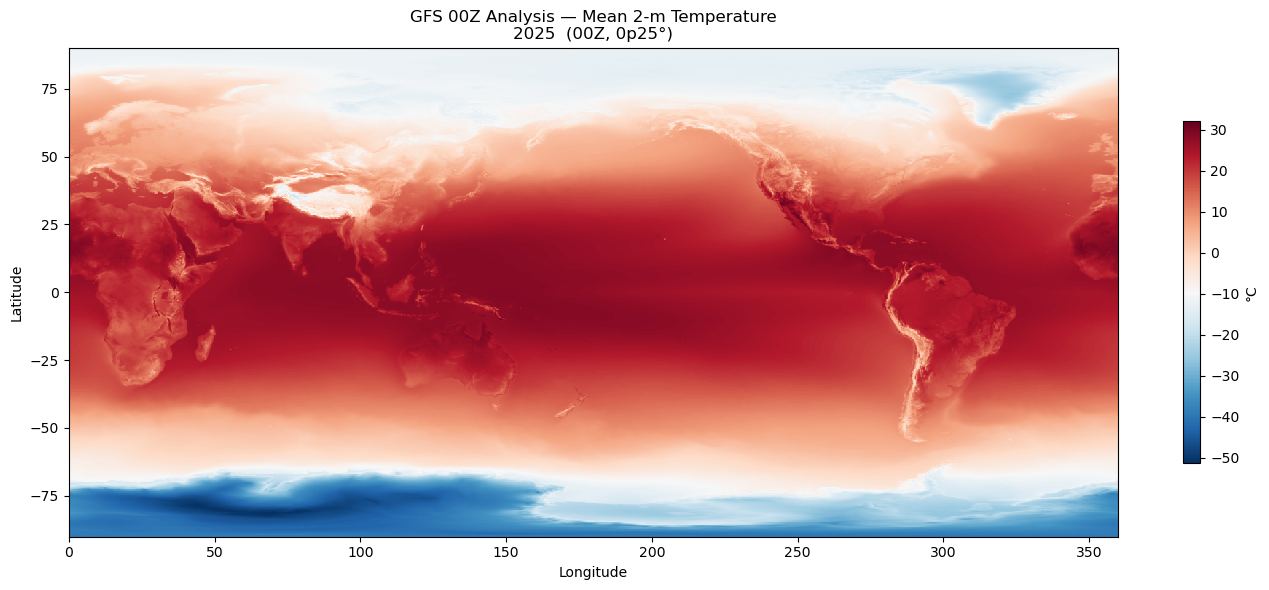

In [7]:
import time

print("Computing monthly mean …")


def compute_with_retries(arr, *, max_attempts=6, base_sleep=2):
    """Retry lazy S3-backed compute on transient timeout/network errors."""
    for attempt in range(1, max_attempts + 1):
        try:
            return arr.compute()
        except Exception as exc:
            msg = str(exc).lower()
            transient = "icechunkerror" in type(exc).__name__.lower() or "timeout" in msg or "timed out" in msg or "connect" in msg
            if (not transient) or attempt == max_attempts:
                raise
            sleep_s = base_sleep**attempt
            print(f"Transient read error ({type(exc).__name__}) on attempt {attempt}/{max_attempts}; retrying in {sleep_s}s...")
            time.sleep(sleep_s)


def resilient_time_mean(arr, *, dim="valid_time", block=7):
    """Compute mean in small retried blocks to avoid one huge remote read graph."""
    n = int(arr.sizes[dim])
    weighted_sums = []
    weights = []
    for start in range(0, n, block):
        stop = min(start + block, n)
        print(f"  block {start}:{stop} ...")
        block_mean = compute_with_retries(arr.isel({dim: slice(start, stop)}).mean(dim))
        weight = stop - start
        weighted_sums.append(block_mean * weight)
        weights.append(weight)
    return sum(weighted_sums) / sum(weights)


# Compute in smaller retried chunks rather than a single large remote graph.
t2m_mean = resilient_time_mean(t2m_monthly, dim="valid_time", block=5)

# ---- plot ----------------------------------------------------------------
lats = t2m_mean.coords.get("latitude", t2m_mean.coords.get("y", None))
lons = t2m_mean.coords.get("longitude", t2m_mean.coords.get("x", None))

fig, ax = plt.subplots(figsize=(14, 6))
if lats is not None and lons is not None:
    pcm = ax.pcolormesh(lons, lats, t2m_mean.values, cmap="RdBu_r", shading="auto")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
else:
    pcm = ax.imshow(t2m_mean.values, origin="upper", cmap="RdBu_r", aspect="auto")
    ax.set_xlabel("x index")
    ax.set_ylabel("y index")

plt.colorbar(pcm, ax=ax, label="°C", shrink=0.7)
ax.set_title(f"GFS 00Z Analysis — Mean 2-m Temperature\n{PERIOD_LABEL}  (00Z, {GRID}°)")
plt.tight_layout()
plt.show()

## 5. Point time series

Select the nearest grid point to a location of interest and plot the daily
T2M over the month.  Only the bytes for those specific grid-point chunks
are fetched.

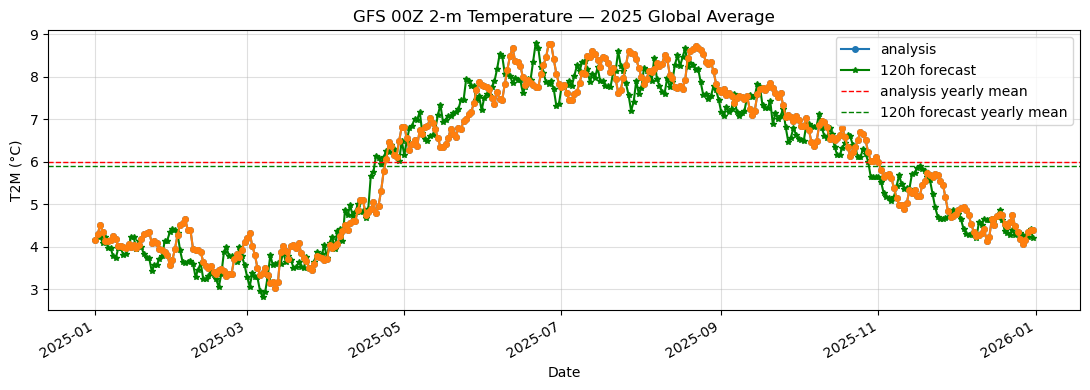


Yearly mean: 5.98 °C
Min: 3.03 °C  on 2025-03-12
Max: 8.77 °C  on 2025-06-27


In [8]:
# Location of interest (change as desired)
TARGET_LAT = 40.71  # New York City
TARGET_LON = -74.01  # (negative = West)

# Reuse retry helper if Cell 4 was run; otherwise provide a local fallback.
if "compute_with_retries" not in globals():
    import time

    def compute_with_retries(arr, *, max_attempts=6, base_sleep=2):
        for attempt in range(1, max_attempts + 1):
            try:
                return arr.compute()
            except Exception as exc:
                msg = str(exc).lower()
                transient = "icechunkerror" in type(exc).__name__.lower() or "timeout" in msg or "timed out" in msg or "connect" in msg
                if (not transient) or attempt == max_attempts:
                    raise
                sleep_s = base_sleep**attempt
                print(f"Transient read error ({type(exc).__name__}) on attempt {attempt}/{max_attempts}; retrying in {sleep_s}s...")
                time.sleep(sleep_s)


lats = t2m_monthly.coords.get("latitude", t2m_monthly.coords.get("y", None))
lons = t2m_monthly.coords.get("longitude", t2m_monthly.coords.get("x", None))

# Compute 1-D global-mean time series with retries and moderate time chunking.
ts = compute_with_retries(t2m_monthly.chunk({"valid_time": 14}).mean("x").mean("y"))
ts120 = compute_with_retries(t2m120.chunk({"valid_time": 14}).mean("x").mean("y"))
times = pd.to_datetime(ts.coords["valid_time"].values)

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(times, ts.values.ravel(), marker="o", linewidth=1.5, markersize=4, label="analysis")
ax.plot(times, ts120.values.ravel(), marker="*", color="green", linewidth=1.5, markersize=4, label="120h forecast")
ax.axhline(float(ts.mean()), color="red", linestyle="--", linewidth=1, label="analysis yearly mean")
ax.axhline(float(ts120.mean()), color="green", linestyle="--", linewidth=1, label="120h forecast yearly mean")
ax.plot(times, ts.values.ravel(), marker="o", linewidth=1.5, markersize=4)
ax.set_xlabel("Date")
ax.set_ylabel("T2M (°C)")
ax.set_title(f"GFS 00Z 2-m Temperature — {PERIOD_LABEL} Global Average")
ax.legend()
ax.grid(alpha=0.4)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

print(f"\nYearly mean: {float(ts.mean()):.2f} °C")
print(f"Min: {float(ts.min()):.2f} °C  on {times[int(ts.argmin())].date()}")
print(f"Max: {float(ts.max()):.2f} °C  on {times[int(ts.argmax())].date()}")

## 6. Spatial standard deviation — day-to-day variability

Where is month-to-month variability highest?  Compute standard deviation
along `valid_time` and plot.

Computing temporal standard deviation …
Transient read error (IcechunkError) on attempt 1/6; retrying in 2s...
Transient read error (IcechunkError) on attempt 2/6; retrying in 4s...
Transient read error (IcechunkError) on attempt 1/6; retrying in 2s...
Transient read error (IcechunkError) on attempt 2/6; retrying in 4s...
Transient read error (IcechunkError) on attempt 3/6; retrying in 8s...
Transient read error (IcechunkError) on attempt 4/6; retrying in 16s...
Transient read error (IcechunkError) on attempt 5/6; retrying in 32s...


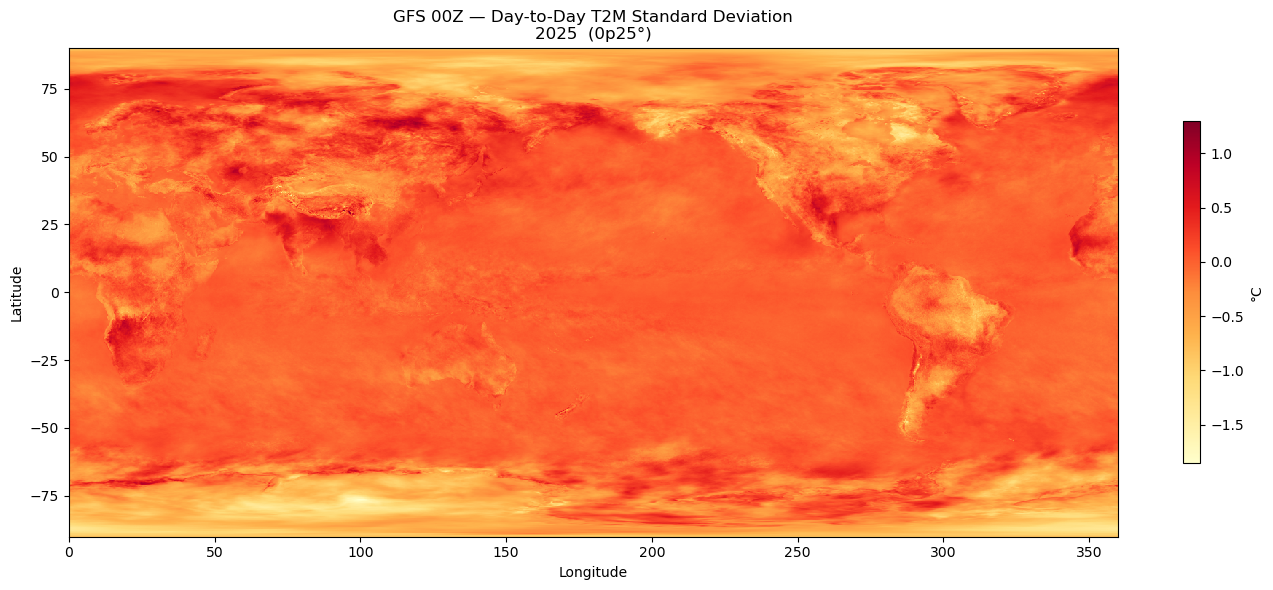

In [9]:
print("Computing temporal standard deviation …")

# Reuse retry helper if Cell 4 was run; otherwise provide a local fallback.
if "compute_with_retries" not in globals():
    import time

    def compute_with_retries(arr, *, max_attempts=6, base_sleep=2):
        for attempt in range(1, max_attempts + 1):
            try:
                return arr.compute()
            except Exception as exc:
                msg = str(exc).lower()
                transient = "icechunkerror" in type(exc).__name__.lower() or "timeout" in msg or "timed out" in msg or "connect" in msg
                if (not transient) or attempt == max_attempts:
                    raise
                sleep_s = base_sleep**attempt
                print(f"Transient read error ({type(exc).__name__}) on attempt {attempt}/{max_attempts}; retrying in {sleep_s}s...")
                time.sleep(sleep_s)


# Smaller time chunks reduce pressure when reducing over a full year.
t2m_std = compute_with_retries(t2m_monthly.chunk({"valid_time": 7}).std("valid_time"))
t2m120_std = compute_with_retries(t2m120.chunk({"valid_time": 7}).std("valid_time"))
lats = t2m_std.coords.get("latitude", t2m_std.coords.get("y", None))
lons = t2m_std.coords.get("longitude", t2m_std.coords.get("x", None))

fig, ax = plt.subplots(figsize=(14, 6))
if lats is not None and lons is not None:
    pcm = ax.pcolormesh(lons, lats, t2m_std - t2m120_std, cmap="YlOrRd", shading="auto")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
else:
    pcm = ax.imshow(t2m_std - t2m120_std, origin="upper", cmap="YlOrRd", aspect="auto")

plt.colorbar(pcm, ax=ax, label="°C", shrink=0.7)
ax.set_title(f"GFS 00Z — Day-to-Day T2M Standard Deviation\n{PERIOD_LABEL}  ({GRID}°)")
plt.tight_layout()
plt.show()